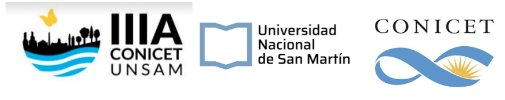  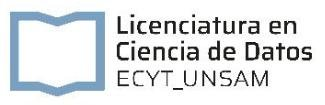

---

# NB05 — Análisis exploratorio del dataset etiquetado

Lo que veremos en esta notebook:

- [x] Firmas espectrales por clase y su interpretación física
- [x] Histogramas, boxplots y violinplots: tres herramientas con historias distintas
- [x] Corrección del etiquetado: la clase `rural` como caso de estudio
- [x] Matrices de covarianza por clase y correlaciones entre bandas
- [x] Separabilidad: distancias de Bhattacharyya y Jeffries-Matusita
- [x] Reducción dimensional con PCA: qué conserva y qué pierde
- [x] El tríptico de la estadística espacial como cierre conceptual
---

### Objetivos de la notebook

Al terminar esta clase esperamos que puedas:

- Construir e interpretar la firma espectral de una clase de cobertura y relacionarla con las propiedades físicas del material.
- Elegir la visualización apropiada (histograma / boxplot / violin) según la pregunta que se quiere responder.
- Detectar clases mal etiquetadas o internamente heterogéneas, corregirlas y regenerar el dataset.
- Calcular distancias de separabilidad entre clases y usar esa información para anticipar qué clasificará bien un modelo.
- Aplicar PCA al espacio espectral e interpretar las componentes resultantes.
- Ubicar el curso dentro del marco conceptual de la estadística espacial en sus tres ramas.

### Datos con los que trabajaremos

- `data/proc/dataset_etiquetado.npz` — producido en NB04: 6 features por píxel, etiquetas de 5 clases, IDs de ROI origen.
- `data/raw_data/vectorial/rois_dique.geojson` — ROIs originales; los vamos a corregir en la sección 3.
- `data/raw_data/satelital/S2_AMBANO_B02B03B04B08_2026feb.tif` — imagen de referencia para visualizar los ROIs.

### Conexión con el arco del curso

Esta notebook tiene dos funciones complementarias. Por un lado es un **diagnóstico del dataset de entrenamiento** antes de usarlo en las notebooks de clustering y clasificación: descubrimos qué pares de clases van a confundirse, detectamos una clase mal etiquetada y la corregimos, y vemos la separabilidad con los datos limpios. Por otro, cerramos el primer tramo con la introducción del **tríptico de la estadística espacial**: las tres ramas que van a organizar la segunda mitad del cuatrimestre.

---
# 0. Bibliotecas

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio
from rasterio.mask import mask as rasterio_mask
import geopandas as gpd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from ade_tools import componer_rgb, ecualizar_rgb, extraer_pixeles_por_roi

RAW  = 'data/raw_data/'
PROC = 'data/proc/'
OUT  = 'data/out/'

FN_IMG  = RAW + 'satelital/S2_AMBANO_B02B03B04B08_2026feb.tif'
FN_ROIS = RAW + 'vectorial/rois_dique.geojson'
FN_ZONA = RAW + 'vectorial/zona_dique.geojson'

# Cargamos el dataset etiquetado producido en NB04
data = np.load(PROC + 'dataset_etiquetado.npz', allow_pickle=True)
X = data['X']
y = data['y']
nombres_features = data['nombres_features'].tolist()

print(f'Dataset cargado: X = {X.shape}, y = {y.shape}')
print(f'Features: {nombres_features}')
print(f'Clases  : {sorted(np.unique(y))}')

# Paleta y orden inicial (5 clases del etiquetado original)
colores = {'agua':'#1f77b4', 'humedal':'#17becf', 'bosque':'#2ca02c',
           'rural':'#8c564b', 'urbano':'#d62728'}
orden   = ['agua', 'humedal', 'bosque', 'rural', 'urbano']

---
# 1. La firma espectral de una cobertura

La **firma espectral** de un material es su perfil de reflectancia en función de la longitud de onda. Cada cobertura del suelo tiene una firma característica derivada de su composición física y química:

- La **vegetación activa** absorbe fuerte en el azul y el rojo (fotosíntesis) y refleja intensamente en el NIR (estructura interna de las hojas — el "red edge").
- El **agua** absorbe casi todo el NIR y refleja poco en todo el visible, con un pico tenue en el azul.
- El **suelo desnudo** tiene una curva relativamente plana que aumenta suavemente hacia el NIR.
- El **urbano** es heterogéneo: los techos, calles y patios son todos espectralmente distintos; la firma promedio es intermedia y plana.

Las firmas espectrales son el fundamento físico de los índices espectrales: NDVI funciona porque la diferencia entre NIR y rojo es grande en vegetación y chica en casi todo lo demás (Tucker, 1979).

In [ ]:
clases = sorted(np.unique(y))

# Centros de banda de Sentinel-2 L2A en nm (aproximados)
wavelength = [490, 560, 665, 842]   # B02 B03 B04 B08
band_names = ['B02\nAzul', 'B03\nVerde', 'B04\nRojo', 'B08\nNIR']

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.set_facecolor('white')

# Panel izquierdo: firmas promedio
for clase in clases:
    mask = y == clase
    media = X[mask, :4].mean(axis=0)
    axes[0].plot(wavelength, media, 'o-', color=colores[clase],
                 label=f'{clase} (n={mask.sum()})', linewidth=2, markersize=7)
axes[0].set_xticks(wavelength); axes[0].set_xticklabels(band_names)
axes[0].set_ylabel('Reflectancia')
axes[0].set_title('Firma espectral media por clase')
axes[0].legend(loc='upper left')
axes[0].grid(alpha=0.3)

# Panel derecho: firmas con banda de ±1 desvío estándar
for clase in clases:
    mask = y == clase
    media = X[mask, :4].mean(axis=0)
    std   = X[mask, :4].std(axis=0)
    axes[1].fill_between(wavelength, media-std, media+std,
                         color=colores[clase], alpha=0.15)
    axes[1].plot(wavelength, media, 'o-', color=colores[clase],
                 linewidth=2, markersize=6, label=clase)
axes[1].set_xticks(wavelength); axes[1].set_xticklabels(band_names)
axes[1].set_ylabel('Reflectancia')
axes[1].set_title('Firma con banda de ±1 desvío estándar')
axes[1].legend(loc='upper left', fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle('Firmas espectrales — Sentinel-2 feb 2026 (etiquetado inicial)', fontsize=13)
plt.tight_layout()
plt.show()

El panel derecho es más honesto: muestra que las firmas no son líneas sino **distribuciones**. Donde las bandas de un color se superponen con las de otro, las clases van a confundirse. Algunas observaciones:

- `agua` es la única clase que **no sube en NIR** (cae levemente de B04 a B08). Esa diferencia cualitativa la separa fácilmente del resto.
- `urbano` se distingue por su **reflectancia alta en el visible** y un salto al NIR mucho menos pronunciado que la vegetación. Es la otra clase fácil de aislar.
- `bosque`, `humedal` y `rural` comparten el perfil clásico de vegetación: salto red-NIR pronunciado y visible bajo. El NDVI las agrupa contra `agua` y `urbano` pero **no las separa entre sí**.

**Una señal de alerta:** la firma de `rural` tiene una dispersión inusualmente amplia (la banda sombreada es muy ancha). Eso sugiere que la clase agrupa coberturas espectralmente heterogéneas. Lo vamos a investigar en la sección 3.

---
# 2. Histograma, boxplot y violin: tres formas de ver una distribución

Las tres herramientas son complementarias, no sustitutivas. Un breve repaso de qué resuelve cada una:

**Histograma.** La forma moderna aparece en Pearson (1895) al formalizar "histogramas de frecuencias" como objeto estadístico, aunque Playfair ya los usaba gráficamente en 1786. Describe la distribución empírica completa discretizando el eje $x$ en *bins*. Requiere elegir ancho del bin: chico introduce ruido, grande oculta estructura. Una regla útil es Freedman-Diaconis, $h = 2 \cdot \text{IQR} / n^{1/3}$, donde **IQR** (del inglés *interquartile range*; en español, **rango intercuartílico**, Q3-Q1) es un estimador robusto de dispersión.

**Boxplot** (Tukey, *EDA*, 1977). Diseñado para comunicar un resumen **robusto** con un dibujo mínimo: mediana, Q1, Q3, y los *whiskers* en $\pm 1.5 \cdot \text{IQR}$. Todos sus componentes son estimadores resistentes a outliers; es útil cuando querés comparar muchas distribuciones a la vez sin que cada una esté dominada por sus colas. Precio: **oculta bimodalidades** — dos distribuciones mezcladas pueden parecer una sola distribución ancha.

**Violinplot** (Hintze & Nelson, *American Statistician*, 1998). Combina la silueta del boxplot con una estimación de densidad kernel en ambos flancos. Muestra la forma completa —incluyendo multimodalidades— y permite comparar muchas distribuciones como el boxplot. Es la opción por defecto cuando tenés dudas sobre la forma de la distribución.

Veámoslos sobre el NDVI por clase, la variable que esperamos más discriminante:

In [ ]:
df = pd.DataFrame(X, columns=nombres_features)
df['clase'] = y

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.set_facecolor('white')
palette = {c: colores[c] for c in orden}

# Histograma (densidad para comparar clases con distinto n)
for clase in orden:
    datos = df[df.clase == clase]['NDVI']
    axes[0].hist(datos, bins=50, alpha=0.4, color=colores[clase], label=clase, density=True)
axes[0].set_xlabel('NDVI'); axes[0].set_ylabel('Densidad')
axes[0].set_title('Histograma por clase (densidad)')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Boxplot
sns.boxplot(data=df, x='clase', y='NDVI', order=orden, palette=palette, ax=axes[1])
axes[1].set_title('Boxplot')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)

# Violin
sns.violinplot(data=df, x='clase', y='NDVI', order=orden, palette=palette,
               inner='quartile', ax=axes[2])
axes[2].set_title('Violinplot (con cuartiles internos)')
axes[2].tick_params(axis='x', rotation=30)
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('NDVI por clase — tres vistas de la misma información (etiquetado inicial)', fontsize=13)
plt.tight_layout()
plt.show()

Lecturas de esta figura:

- `agua` está completamente aislada en NDVI negativo, sin solapamiento con ninguna otra clase.
- `bosque` y `humedal` tienen superposición apreciable en NDVI alto — el histograma con múltiples clases superpuestas hace difícil cuantificarla; el boxplot y el violin lo muestran mejor.
- `rural` muestra **bimodalidad clara en el violin**: hay dos modos bien separados dentro de la misma clase. El boxplot la oculta. Esto nos dice que la etiqueta `rural` agrupa coberturas espectralmente distintas — un problema real para cualquier clasificador.

Esta observación es el punto de partida de la sección 3.

**Decisión práctica:** en el resto del curso usaremos violin o boxplot cuando comparemos clases, e histogramas cuando miremos una distribución individual o necesitemos diagnosticar outliers.

### Ejercicio guiado 2.1

Generá un violinplot para cada una de las 6 features del dataset (`B02, B03, B04, B08, NDVI, NDWI`). ¿Cuál muestra la **separación** más clara entre las 5 clases? ¿Cuál la peor? Anotá tus observaciones sobre `rural` en cada feature.

In [ ]:
# Tu código acá


---
# 3. Corrección del etiquetado: la clase `rural` es dos clases

## 3.0 Por qué este paso es obligatorio

El etiquetado de coberturas del suelo no es una tarea mecánica. Un error muy común es agrupar bajo una misma etiqueta coberturas que son visualmente parecidas a simple vista pero espectralmente distintas. Cuando eso ocurre, el clasificador aprende una clase con distribución multimodal que no puede separar bien.

La bimodalidad de `rural` en el violinplot del NDVI no es un accidente: hay dos tipos de superficie bien distintos dentro de esa categoría. El objetivo de esta sección es:

1. Identificar el umbral que los separa.
2. Clasificar cada ROI rural en su subclase correcta.
3. Visualizar geoespacialmente la distribución de los dos tipos.
4. Nombrar las subclases a partir de lo que observamos en la imagen.
5. Corregir el GeoJSON y regenerar el dataset.

**El dataset corregido que generemos acá es el que vamos a usar en todo lo que sigue del curso.** No se puede avanzar a la clasificación supervisada con las etiquetas originales.

---

## 3.1 Diagnóstico visual: foco en `rural`

In [ ]:
# Zoom sobre la distribución NDVI de rural únicamente
X_rural = X[y == 'rural']
print(f'Píxeles con etiqueta rural: {len(X_rural)}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.set_facecolor('white')

# Histograma con muchos bins para ver el valle entre modos
axes[0].hist(X_rural[:, 4], bins=80, color='#8c564b', edgecolor='white',
             linewidth=0.3, alpha=0.85)
axes[0].set_xlabel('NDVI'); axes[0].set_ylabel('Número de píxeles')
axes[0].set_title('Histograma NDVI — clase rural')
axes[0].grid(axis='y', alpha=0.3)

# Violin individual
sns.violinplot(y=X_rural[:, 4], ax=axes[1], color='#8c564b', inner='quartile')
axes[1].set_ylabel('NDVI')
axes[1].set_title('Violin — clase rural')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Bimodalidad en la clase rural — ¿dónde está el valle?', fontsize=12)
plt.tight_layout()
plt.show()

# Estadísticos resumen
print(f'NDVI rural — min: {X_rural[:,4].min():.3f}  max: {X_rural[:,4].max():.3f}')
print(f'Percentiles: P10={np.percentile(X_rural[:,4],10):.3f}  '
      f'P25={np.percentile(X_rural[:,4],25):.3f}  '
      f'P50={np.percentile(X_rural[:,4],50):.3f}  '
      f'P75={np.percentile(X_rural[:,4],75):.3f}  '
      f'P90={np.percentile(X_rural[:,4],90):.3f}')

---

## 3.2 Definición del umbral

In [ ]:
# ── A COMPLETAR ──────────────────────────────────────────────────────────────
# Mirá el histograma y el violinplot de arriba.
# Identificá el valle entre los dos modos: es el valor de NDVI donde
# la densidad cae entre el pico inferior y el pico superior.
# Editá el valor de UMBRAL_NDVI_RURAL con lo que observaste:

UMBRAL_NDVI_RURAL = 0.25   # ← ajustar según el valle que ves en tu figura

# Verificamos que el umbral tenga sentido: debería separar los datos en dos grupos razonables
n_bajo = (X_rural[:, 4] <  UMBRAL_NDVI_RURAL).sum()
n_alto = (X_rural[:, 4] >= UMBRAL_NDVI_RURAL).sum()
print(f'Con NDVI < {UMBRAL_NDVI_RURAL}: {n_bajo} píxeles ({100*n_bajo/len(X_rural):.0f}%)')
print(f'Con NDVI ≥ {UMBRAL_NDVI_RURAL}: {n_alto} píxeles ({100*n_alto/len(X_rural):.0f}%)')

# Visualizamos el umbral sobre el histograma
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(X_rural[:, 4], bins=80, color='#8c564b', edgecolor='white', linewidth=0.3, alpha=0.85)
ax.axvline(UMBRAL_NDVI_RURAL, color='black', linewidth=2, linestyle='--',
           label=f'Umbral NDVI = {UMBRAL_NDVI_RURAL}')
ax.set_xlabel('NDVI'); ax.set_ylabel('Píxeles')
ax.set_title('Umbral de separación de la clase rural')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

---

## 3.3 Calcular NDVI medio por ROI rural y asignar subclase

In [ ]:
# Cargamos los ROIs y seleccionamos los rurales
gdf_rois = gpd.read_file(FN_ROIS)
gdf_rural = gdf_rois[gdf_rois['clase'] == 'rural'].copy()

print(f'ROIs rurales: {len(gdf_rural)} polígonos')
print()

# Para cada ROI calculamos el NDVI medio de sus píxeles en la imagen original
ESCALA = 10_000.0
ndvi_por_roi = {}
with rasterio.open(FN_IMG) as src:
    crs_img = src.crs
    gdf_rural_utm = gdf_rural.to_crs(crs_img)
    for idx, row in gdf_rural_utm.iterrows():
        try:
            recorte, _ = rasterio_mask(src, [row.geometry.__geo_interface__],
                                        crop=True, filled=True)
            rojo = recorte[2].astype(float) / ESCALA
            nir  = recorte[3].astype(float) / ESCALA
            ndvi = np.where((nir + rojo) > 0, (nir - rojo) / (nir + rojo), np.nan)
            ndvi_por_roi[idx] = float(np.nanmean(ndvi))
        except Exception:
            ndvi_por_roi[idx] = np.nan

gdf_rural['ndvi_medio'] = gdf_rural.index.map(ndvi_por_roi)
print('NDVI medio por ROI rural (ordenado):')
print(gdf_rural[['clase', 'ndvi_medio']].sort_values('ndvi_medio').to_string())

In [ ]:
# ── A COMPLETAR ──────────────────────────────────────────────────────────────
# Elegí nombres descriptivos para las dos subclases.
# Después de ver la imagen en la celda siguiente, actualizá si es necesario.
# Ejemplos posibles: 'pastizal'/'suelo_campo', 'campo_verde'/'campo_seco', etc.

NOMBRE_RURAL_ALTO = '???'   # ← ROIs con NDVI ≥ UMBRAL (vegetación): ponerle nombre
NOMBRE_RURAL_BAJO = '???'   # ← ROIs con NDVI <  UMBRAL (sin vegetación): ponerle nombre

gdf_rural['clase_nueva'] = gdf_rural['ndvi_medio'].apply(
    lambda v: NOMBRE_RURAL_ALTO if v >= UMBRAL_NDVI_RURAL else NOMBRE_RURAL_BAJO
)

print('Asignación de ROIs rurales:')
print(gdf_rural[['ndvi_medio', 'clase_nueva']].sort_values('ndvi_medio').to_string())
print()
print(f'ROIs en "{NOMBRE_RURAL_ALTO}": {(gdf_rural.clase_nueva == NOMBRE_RURAL_ALTO).sum()}')
print(f'ROIs en "{NOMBRE_RURAL_BAJO}": {(gdf_rural.clase_nueva == NOMBRE_RURAL_BAJO).sum()}')

---

## 3.4 Visualización geoespacial — ¿qué son las dos subclases?

In [ ]:
# Recortamos la imagen a la zona del Dique para el fondo RGB
gdf_zona = gpd.read_file(FN_ZONA).to_crs(crs_img)
with rasterio.open(FN_IMG) as src:
    imagen_zona, T_zona = rasterio_mask(
        src, [gdf_zona.geometry.iloc[0].__geo_interface__], crop=True)

from rasterio.plot import plotting_extent
extent = plotting_extent(imagen_zona[0], T_zona)
gdf_rural_utm = gdf_rural.to_crs(crs_img)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.set_facecolor('white')

# Panel izquierdo: color natural ecualizado
axes[0].imshow(ecualizar_rgb(imagen_zona, [2, 1, 0]), extent=extent)
for clase, color in [(NOMBRE_RURAL_BAJO, '#ff7f0e'), (NOMBRE_RURAL_ALTO, '#2ca02c')]:
    sub = gdf_rural_utm[gdf_rural_utm['clase_nueva'] == clase]
    if len(sub) > 0:
        sub.plot(ax=axes[0], edgecolor=color, facecolor='none',
                 linewidth=2.5, label=clase)
axes[0].legend(loc='lower right', framealpha=0.9, fontsize=9)
axes[0].set_title('Color natural ecualizado — ROIs rurales subdivididos')
axes[0].set_axis_off()

# Panel derecho: composición NIR-R-G (vegetación en rojo brillante)
axes[1].imshow(ecualizar_rgb(imagen_zona, [3, 2, 1]), extent=extent)
for clase, color in [(NOMBRE_RURAL_BAJO, '#ff7f0e'), (NOMBRE_RURAL_ALTO, '#2ca02c')]:
    sub = gdf_rural_utm[gdf_rural_utm['clase_nueva'] == clase]
    if len(sub) > 0:
        sub.plot(ax=axes[1], edgecolor=color, facecolor='none',
                 linewidth=2.5, label=clase)
axes[1].legend(loc='lower right', framealpha=0.9, fontsize=9)
axes[1].set_title('Falso color NIR-R-G — vegetación activa en rojo')
axes[1].set_axis_off()

plt.suptitle('¿Qué ves en cada tipo de ROI? → terminá de nombrarlo', fontsize=12)
plt.tight_layout()
plt.show()

**¿Qué buscar en estas imágenes?**

- En la composición de color natural (izquierda): los ROIs de baja NDVI deberían verse en tonos beige-ocre (suelo desnudo o pastizal seco); los de alta NDVI en tonos verdes.
- En la composición NIR-R-G (derecha): la vegetación activa aparece en rojo brillante. Los ROIs con alta NDVI deberían verse claramente rojos; los de baja NDVI, en gris-marrón.

Observá la imagen, ajustá `NOMBRE_RURAL_ALTO` y `NOMBRE_RURAL_BAJO` con nombres que describan lo que realmente estás viendo, y corregí el umbral si es necesario antes de continuar.

---

## 3.5 Modificar el GeoJSON y regenerar el dataset

In [ ]:
# Actualizamos el GeoDataFrame completo con las nuevas etiquetas rurales
gdf_rois_corr = gdf_rois.copy()
for idx, row in gdf_rural.iterrows():
    gdf_rois_corr.at[idx, 'clase'] = row['clase_nueva']

print('Clases en el GeoDataFrame corregido:')
print(gdf_rois_corr.groupby('clase').size().rename('n_polígonos').to_string())

# Guardamos el GeoJSON corregido (no pisamos el original)
fn_rois_corr = RAW + 'vectorial/rois_dique_corregido.geojson'
gdf_rois_corr.to_file(fn_rois_corr, driver='GeoJSON')
print(f'\nGuardado: {fn_rois_corr}')

In [ ]:
# Regeneramos el dataset con las etiquetas corregidas
gdf_rois_corr_utm = gdf_rois_corr.to_crs(crs_img)
X_bandas, y, ids_roi = extraer_pixeles_por_roi(FN_IMG, gdf_rois_corr_utm)

ESCALA = 10_000.0
azul  = X_bandas[:, 0] / ESCALA
verde = X_bandas[:, 1] / ESCALA
rojo  = X_bandas[:, 2] / ESCALA
nir   = X_bandas[:, 3] / ESCALA

ndvi_px = np.where((nir + rojo) != 0, (nir - rojo) / (nir + rojo), np.nan)
ndwi_px = np.where((verde + nir) != 0, (verde - nir) / (verde + nir), np.nan)
X = np.column_stack([X_bandas / ESCALA, ndvi_px, ndwi_px])

print(f'Dataset corregido: X = {X.shape},  y = {y.shape}')
print(f'Clases nuevas    : {sorted(np.unique(y))}')
print()
print('Píxeles por clase:')
vals, counts = np.unique(y, return_counts=True)
for v, c in zip(vals, counts):
    print(f'  {v:20s} : {c:6d}')

np.savez(PROC + 'dataset_etiquetado_corregido.npz',
         X=X, y=y, ids_roi=ids_roi,
         nombres_features=np.array(['B02','B03','B04','B08','NDVI','NDWI']))
print(f'\nGuardado: {PROC}dataset_etiquetado_corregido.npz')

In [ ]:
# Actualizamos paleta y orden para el resto de la notebook
# (ahora tenemos 6 clases en lugar de 5)
colores[NOMBRE_RURAL_BAJO] = '#c49c94'   # tono claro del marrón original
colores[NOMBRE_RURAL_ALTO] = '#98df8a'   # verde claro
if 'rural' in colores:
    del colores['rural']

clases = sorted(np.unique(y))
orden  = [c for c in ['agua','humedal','bosque', NOMBRE_RURAL_ALTO,
                       NOMBRE_RURAL_BAJO, 'urbano'] if c in clases]

print('Paleta actualizada:')
for c in clases:
    print(f'  {c}: {colores.get(c, "sin color — agregar al dict")}')

---

## 3.6 Visualizaciones clave con el dataset corregido

In [ ]:
# Repetimos firmas espectrales y violinplot con las etiquetas corregidas
df = pd.DataFrame(X, columns=nombres_features)
df['clase'] = y
palette = {c: colores[c] for c in clases if c in colores}

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.set_facecolor('white')

# Firmas espectrales
for clase in clases:
    mask = y == clase
    media = X[mask, :4].mean(axis=0)
    std   = X[mask, :4].std(axis=0)
    col   = colores.get(clase, 'gray')
    axes[0].fill_between(wavelength, media-std, media+std, color=col, alpha=0.15)
    axes[0].plot(wavelength, media, 'o-', color=col, linewidth=2, markersize=6, label=clase)
axes[0].set_xticks(wavelength); axes[0].set_xticklabels(band_names)
axes[0].set_ylabel('Reflectancia')
axes[0].set_title('Firmas espectrales — etiquetado corregido')
axes[0].legend(loc='upper left', fontsize=8); axes[0].grid(alpha=0.3)

# Violinplot NDVI
sns.violinplot(data=df, x='clase', y='NDVI', order=orden,
               palette=palette, inner='quartile', ax=axes[1])
axes[1].set_title('NDVI por clase — etiquetado corregido')
axes[1].tick_params(axis='x', rotation=35)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Comparación visual antes / después de la corrección', fontsize=13)
plt.tight_layout()
plt.show()

**¿Qué cambió?** Las dos subclases rurales deberían ahora mostrarse como distribuciones unimodales y bien separadas entre sí. La firma espectral de cada una debería ser más "limpia" (menor dispersión) que la clase `rural` original.

A partir de acá **todo el análisis usa el dataset corregido**: `X`, `y`, `clases` y `colores` ya están actualizados en memoria.

---
# 4. Covarianza por clase y estructura del espacio de features

Una firma espectral describe el centro de la distribución de una clase, pero no su forma. Dos clases pueden tener firmas parecidas con covarianzas muy distintas —una forma en el espacio de features de diferente elongación y orientación— y eso afecta la separabilidad. La covarianza por clase es la información que explotan clasificadores basados en modelos gaussianos (LDA, QDA, GMM) y el núcleo de la distancia de Bhattacharyya.

In [ ]:
# Correlación entre features (global, sin distinguir clase)
corr = pd.DataFrame(X, columns=nombres_features).corr()

fig, ax = plt.subplots(figsize=(7, 6))
fig.set_facecolor('white')
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, cbar_kws={'shrink':0.8}, ax=ax)
ax.set_title('Correlación entre las 6 features (dataset corregido, global)')
plt.tight_layout()
plt.show()

Observaciones típicas de este heatmap:

- `B02, B03, B04` (bandas visibles) están **altamente correlacionadas entre sí**: lo que es brillante en azul suele ser brillante en verde y rojo. Agregar las tres bandas visibles aporta menos información nueva de lo que parece.
- `NDVI` correlaciona fuertemente con `B08` (NIR) y anti-correlaciona con `B04` (rojo), por construcción.
- `NDWI` correlaciona negativamente con `NDVI`, como se espera — ambos responden al NIR en sentido opuesto.
- Si la correlación NDVI/NDWI es exactamente -1.00 (o muy cercana), eso es una señal de alerta: revisa cómo calculaste NDWI en NB04. La correlación esperada es alta en módulo (~0.85–0.95) pero no perfecta, porque NDWI usa GREEN mientras que NDVI usa RED.

La alta correlación entre features tiene consecuencias: **features redundantes hacen sobrestimar la importancia** de cada variable individual. Al clasificar hay que tener esto presente.

---
# 5. Separabilidad entre clases: Bhattacharyya y Jeffries-Matusita

Hasta ahora miramos las clases *de a una* o comparamos visualmente. Ahora queremos una medida numérica de cuán separables son dos clases en el espacio de features. Si dos clases no son separables con las features que tenemos, ningún clasificador las va a distinguir — la pelea la perdimos antes de empezar.

## 5.1 La distancia de Bhattacharyya

Para dos distribuciones gaussianas multivariadas $\mathcal{N}(\mu_1, \Sigma_1)$ y $\mathcal{N}(\mu_2, \Sigma_2)$:

$$B(1,2) = \frac{1}{8}(\mu_1 - \mu_2)^T\, \bar\Sigma^{\,-1}\, (\mu_1 - \mu_2) + \frac{1}{2} \ln \frac{\det \bar\Sigma}{\sqrt{\det \Sigma_1 \det \Sigma_2}}$$

donde $\bar\Sigma = (\Sigma_1 + \Sigma_2)/2$ es la covarianza promedio de las dos clases.

El primer término es la distancia de Mahalanobis normalizada. El segundo penaliza diferencia de formas: dos gaussianas con el mismo centro pero covarianzas distintas tienen $B > 0$.

## 5.2 La distancia de Jeffries-Matusita

$$\text{JM}(1, 2) = 2\left(1 - e^{-B(1,2)}\right), \quad \text{JM} \in [0, 2]$$

La cota de Fukunaga (1990, cap. 3) conecta JM con la probabilidad de error del clasificador óptimo de Bayes:

$$P_e \leq \tfrac{1}{2}\, e^{-B}$$

| JM | Cota $P_e$ | Interpretación |
|---|---|---|
| 0.0 – 1.0 | ≥ 19% | Muy confundidas. |
| 1.0 – 1.7 | 5–19% | Separabilidad moderada. Errores sistemáticos. |
| 1.7 – 1.9 | 1.7–5% | Buena. Errores esporádicos. |
| 1.9 – 2.0 | < 1.7% | Excelente. |

Referencias: Jeffreys (1946); Matusita (1967); Swain & Davis (1978); Fukunaga (1990).

In [ ]:
def jeffries_matusita(X1, X2):
    """
    Distancia de Jeffries-Matusita entre dos matrices de features.
    X1, X2: arrays (n, d) con una fila por observación.
    Usa slogdet para estabilidad numérica con covarianzas casi singulares.
    """
    mu1, mu2 = X1.mean(axis=0), X2.mean(axis=0)
    S1, S2   = np.cov(X1.T), np.cov(X2.T)
    S        = (S1 + S2) / 2
    delta    = mu1 - mu2

    t1 = 0.125 * delta @ np.linalg.solve(S, delta)

    sign_S,  logdet_S  = np.linalg.slogdet(S)
    sign_S1, logdet_S1 = np.linalg.slogdet(S1)
    sign_S2, logdet_S2 = np.linalg.slogdet(S2)

    if sign_S <= 0 or sign_S1 <= 0 or sign_S2 <= 0:
        return np.nan

    t2 = 0.5 * (logdet_S - 0.5 * (logdet_S1 + logdet_S2))
    B  = t1 + t2
    return 2 * (1 - np.exp(-B))

> **`jeffries_matusita()` → `ade_tools.py`**

**Por qué `slogdet` y no `det`**: el determinante de una covarianza con 6 features correlacionadas puede ser del orden de $10^{-30}$. `slogdet` calcula el log-determinante directamente de la factorización LU, evitando overflow/underflow.

In [ ]:
# ── Matriz JM con el dataset corregido ────────────────────────────────────────
n_clases = len(clases)
JM = np.zeros((n_clases, n_clases))
for i, c1 in enumerate(clases):
    for j, c2 in enumerate(clases):
        JM[i, j] = 0 if i == j else jeffries_matusita(X[y == c1], X[y == c2])

fig, ax = plt.subplots(figsize=(9, 8))
fig.set_facecolor('white')
sns.heatmap(JM, annot=True, fmt='.3f', cmap='YlOrRd_r', vmin=0, vmax=2,
            xticklabels=clases, yticklabels=clases,
            cbar_kws={'label': 'JM (2 = perfectamente separable)'}, ax=ax)
ax.set_title('Distancia de Jeffries-Matusita — etiquetado corregido')
plt.tight_layout()
plt.show()

# Imprimimos los pares con JM < 1.9 para identificar los problemáticos
print('Pares con JM < 1.9 (posibles fuentes de error en la clasificación):')
for i, c1 in enumerate(clases):
    for j, c2 in enumerate(clases):
        if i < j and JM[i,j] < 1.9:
            print(f'  {c1:20s} × {c2:20s} : {JM[i,j]:.3f}')

**¿Mejoró la separabilidad respecto al etiquetado original?** Antes, `rural` tenía una distribución bimodal que al forzarse a una única gaussiana produce covarianza inflada. Al separar en dos clases unimodales, cada una debería dar distancias JM más precisas y razonables con el resto.

**Predicción para la clasificación supervisada.** Guardemos el par con **menor JM** de la matriz. Cuando calculemos la matriz de confusión del clasificador sobre K-fold espacial, ese par va a ser —con altísima probabilidad— la fuente principal de errores. Si la predicción se cumple, la geometría gaussiana que asumimos describe bien el problema; si no, el clasificador está capturando estructura no-gaussiana, lo que también es informativo.

---
# 6. Reducción dimensional con PCA

El análisis de componentes principales (PCA) encuentra una rotación ortogonal del espacio de features que maximiza la varianza capturada por las primeras componentes. Es útil para:

- **Visualización**: proyectar 6 dimensiones a 2 o 3 para poder graficar.
- **Descorrelación**: las componentes principales son por construcción ortogonales (correlación cero entre ellas).
- **Compresión**: si las primeras componentes capturan >95% de la varianza, podemos trabajar con menos features.

**Precaución:** PCA maximiza varianza, no separabilidad. Es perfectamente posible que la segunda o tercera componente sea más útil para separar clases que la primera.

In [ ]:
# Estandarizamos y corremos PCA
X_std = StandardScaler().fit_transform(X)
pca   = PCA(n_components=6).fit(X_std)

print('Varianza explicada por componente:')
for i, v in enumerate(pca.explained_variance_ratio_):
    print(f'  CP{i+1}: {v*100:5.2f}%   acumulado: {pca.explained_variance_ratio_[:i+1].sum()*100:5.2f}%')

# Coeficientes de proyección: cuánto contribuye cada feature original a cada CP
# (llamados "loadings" en la literatura anglosajona)
coef_pc = pd.DataFrame(pca.components_.T,
                        index=nombres_features,
                        columns=[f'CP{i+1}' for i in range(6)])
print('\nCoeficientes de proyección (contribución de cada feature a cada CP):')
print(coef_pc.round(3))

In [ ]:
# Interpretación de los coeficientes de las dos primeras componentes
def interpretar_cp(coef_cp_col, nombres, umbral=0.3):
    """Lista las features con coeficiente de proyección mayor al umbral."""
    pesados = [(nombres[i], coef_cp_col.iloc[i])
               for i in range(len(nombres)) if abs(coef_cp_col.iloc[i]) > umbral]
    pesados.sort(key=lambda x: abs(x[1]), reverse=True)
    return pesados

for cp in ['CP1', 'CP2']:
    print(f'{cp} ({pca.explained_variance_ratio_[int(cp[-1])-1]*100:.1f}% var):')
    for nombre, peso in interpretar_cp(coef_pc[cp], nombres_features):
        signo = '+' if peso > 0 else '−'
        print(f'    {signo} {nombre}: {abs(peso):.3f}')
    print()

In [ ]:
# Scatter PC1 × PC2 y CP3 × CP4 con clases coloreadas
X_pca = pca.transform(X_std)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.set_facecolor('white')

for ax, (cx, cy) in zip(axes, [(0, 1), (2, 3)]):
    for clase in clases:
        mask = y == clase
        col  = colores.get(clase, 'gray')
        ax.scatter(X_pca[mask, cx], X_pca[mask, cy],
                   c=col, label=clase, alpha=0.4, s=5)
    ax.set_xlabel(f'CP{cx+1} ({pca.explained_variance_ratio_[cx]*100:.1f}% var)')
    ax.set_ylabel(f'CP{cy+1} ({pca.explained_variance_ratio_[cy]*100:.1f}% var)')
    ax.set_title(f'Proyección en CP{cx+1} × CP{cy+1}')
    ax.legend(fontsize=8, markerscale=3)
    ax.grid(alpha=0.3)

plt.suptitle('Clases en el espacio de componentes principales', fontsize=13)
plt.tight_layout()
plt.show()

**Interpretación.** CP1 suele capturar un eje de "brillo general" — ordena de agua (oscura) a suelo/urbano (brillante). CP2 suele capturar un eje vegetativo, muy correlacionado con NDVI. Las clases se separan mejor en CP1×CP2 que en bandas individuales, porque PCA absorbe la alta correlación entre bandas visibles en una única componente.

Si la proyección CP1×CP2 muestra las clases bien separadas, 2 componentes bastan para clasificar. Si hay solapamientos, necesitaremos las 6 features originales.

---
# 7. El tríptico de la estadística espacial

Hasta acá trabajamos con píxeles como puntos en un espacio de features (ignorando su posición geográfica) y con polígonos censales como entidades sin vecindades. Desde la próxima clase empezamos a considerar explícitamente la **estructura espacial** del dato.

La estadística espacial moderna (Cressie, 1993) organiza sus métodos según la **naturaleza del soporte espacial** del dato:

| Rama | Naturaleza del dato | Pregunta típica | Herramientas |
|---|---|---|---|
| **Procesos de puntos** | Localizaciones $\{x_i\}$; el evento es la variable | ¿Dónde ocurren los eventos? ¿Están agregados? | Función K/L de Ripley, KDE |
| **Datos areales / retícula** | Valores por polígono $\{z(A_i)\}$ | ¿Hay autocorrelación? ¿Dónde están los clústeres? | Moran, LISA, Gi\*, SAR/SEM |
| **Geoestadística** | Mediciones puntuales de variable continua $z(x)$ | ¿Cuánto vale donde no medí? | Variograma, kriging |

## 7.1 Rama 1 — Procesos de puntos

Los datos son **localizaciones** $\{x_1, ..., x_n\}$ en el plano; la localización misma es la variable aleatoria. Ejemplos: asentamientos precarios, nidos, delitos, casos de una enfermedad. Lo trabajamos más adelante con datos de RENABAP sobre nuestro territorio.

## 7.2 Rama 2 — Datos areales / en retícula

Los datos son **agregados en polígonos** $\{A_1, ..., A_n\}$: para cada polígono hay un valor. La posición es dada (las unidades de agregación son fijas) y lo aleatorio es el valor observado. Ejemplos: censo por radio, incidencia por municipio. Lo trabajamos más adelante sobre los radios censales y en la regresión espacial final.

## 7.3 Rama 3 — Geoestadística

Los datos son **mediciones de una variable continua** en localizaciones discretas $\{z(x_1), ..., z(x_n)\}$. La variable tiene un valor potencial en cada punto del plano. Ejemplos: temperatura en estaciones meteorológicas, materia orgánica en muestras de suelo. Lo tratamos como ejercicio opcional hacia el final del curso.

## 7.4 ¿Por qué tres ramas y no una?

Las preguntas son distintas y requieren herramientas distintas, pero hay conexiones profundas: el semivariograma de geoestadística es la generalización natural de la autocorrelación areal; un proceso de puntos con intensidad suave puede aproximarse por datos areales. La división es pedagógica y operativa.

---
# Ejercicios de entrega

---

## Ejercicio 1 — Diagnóstico del dataset y efecto de la corrección

a) Calculá para cada clase el **rango intercuartílico (IQR)** del NDVI usando el dataset corregido. ¿Qué clase tiene más dispersión? ¿Qué implica eso para la clasificación?

b) Identificá outliers de cada clase (fuera de ±2 desvíos estándar) en **al menos una feature**. ¿Qué proporción de píxeles son outliers por clase? Visualizá algunos: ¿parecen errores reales de etiquetado o variabilidad natural?

c) **Efecto de la corrección sobre la separabilidad.** Calculá la distancia JM entre `humedal` y la clase `rural` original (usando el npz sin corregir). Luego calculá JM(`humedal`, subclase_alta) y JM(`humedal`, subclase_baja) con el dataset corregido. ¿Cambia la separabilidad? ¿En qué dirección y por qué tiene sentido físicamente?

---

## Ejercicio 2 — Separabilidad y elección de features

a) Calculá la matriz de JM usando **solo las 4 bandas** (sin NDVI ni NDWI). Compará con la matriz completa. ¿Cuánto mejora la separabilidad al agregar los índices? ¿Para qué pares de clases mejora más?

b) Si tuvieras que elegir **solo 2 features** para clasificar, ¿cuáles elegirías y por qué? Justificá con la matriz JM usando solo esas 2 features.

c) ¿Cuál par de features da la **peor** separabilidad global? ¿Por qué?

---

## Ejercicio 3 — PCA y coeficientes de proyección

a) Con los **coeficientes de proyección** de CP1 y CP2, interpretá físicamente qué mide cada componente. CP1 es típicamente un eje de brillo general y CP2 un eje de vegetación — verificá esto en *nuestros* datos y reportalo con los valores exactos de los coeficientes.

b) Calculá la matriz JM en el espacio de CP1 y CP2 (solo dos componentes). ¿Pierde separabilidad respecto a usar las 6 features originales? ¿En qué pares?

c) Con la información acumulada, escribí 3-4 oraciones prediciendo qué par de clases va a ser el más confundido en la clasificación supervisada. Guardalo: cuando veamos la matriz de confusión del clasificador, verificamos si acertaste.

---

## Ejercicio opcional — Comparación de separabilidad entre fechas

En NB04, Ejercicio 2, generaste `dataset_etiquetado_2015ago.npz` con los mismos ROIs aplicados sobre la imagen de agosto 2015. Este ejercicio usa ese archivo.

a) Calculá la matriz JM para el dataset de 2015. Compará con la matriz del dataset de 2026. ¿Hay pares de clases cuya separabilidad cambia significativamente entre fechas?

b) ¿Hay clases que sean más separables en invierno (agosto) que en verano (febrero)? ¿Tiene sentido físico? Relacionalo con la fenología (ciclo estacional de la vegetación).

c) ¿Qué implicancia tiene esto para el diseño de un clasificador de coberturas: ¿sería mejor usar imágenes de una estación específica, o es más robusto combinar fechas?

*Punteros:* Bruzzone & Serpico (1997) sobre clasificación multi-temporal; Foody & Mathur (2004) sobre separabilidad en imágenes SAR y ópticas.

---
# Apéndice — Estado de `ade_tools.py` al final de esta clase

Incorporamos:

- `jeffries_matusita(X1, X2)` — separabilidad entre dos clases con slogdet.

```python
def jeffries_matusita(X1, X2):
    """Separabilidad JM entre dos clases. Estable numéricamente con slogdet."""
    # [implementación completa, ver sección 5]
```

Con las funciones acumuladas desde NB01:

- `escalar`, `componer_rgb`, `ecualizar_rgb`, `guardar_geotiff` (NB01, NB02)
- `estadisticas_zonales`, `extraer_pixeles_por_roi` (NB04)
- `jeffries_matusita` (NB05)

**Archivos producidos por esta clase:**

- `data/raw_data/vectorial/rois_dique_corregido.geojson` — ROIs con etiquetas corregidas.
- `data/proc/dataset_etiquetado_corregido.npz` — dataset etiquetado con clases limpias.

**Las notebooks siguientes del curso usan `dataset_etiquetado_corregido.npz`.**